In [119]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np
from matplotlib.pyplot import plot
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown, display_markdown # to display images

# Display norm

In [60]:
rec_seq = torch.load("model_outputs/rec_seq_0724_204251_v9.pt")   # [10377, 10, 512]

In [89]:
ori_seq = torch.load("model_outputs/ori_seq_0724_204251_v9.pt")   # [10377, 10, 512]

In [90]:
# For rec_seq
all_rec_norm_list = []
for seq in rec_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_rec_norm_list.append(norm_list)

In [91]:
# For ori_seq
all_ori_norm_list = []
for seq in ori_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_ori_norm_list.append(norm_list)

In [92]:
assert len(all_rec_norm_list) == len(all_ori_norm_list)

In [93]:
all_rec_norm_list[9]

[0.9779276847839355,
 0.973573625087738,
 1.0275431871414185,
 0.40107983350753784,
 0.4880833625793457,
 0.6097118258476257,
 0.676997721195221,
 0.8470544219017029,
 0.7521040439605713,
 0.5765875577926636]

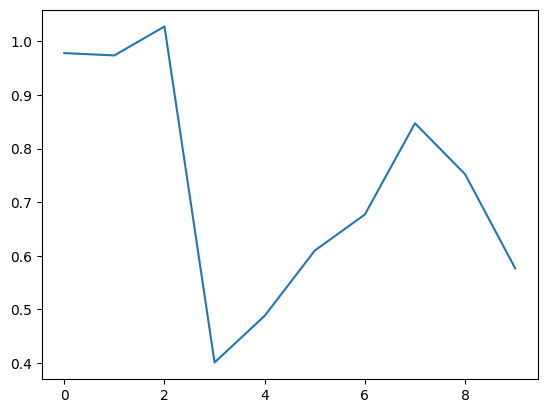

In [94]:
plot(range(10), all_rec_norm_list[9])

# Find closest parts embedding

In [80]:
# find the pad for ori, compute the 'mask'
eps = 0.5
threshold = 0.5

In [3]:
all_emb_path = os.path.join("./processed_data", "mean_pooled_emb.pt")
all_emb = torch.load(all_emb_path)   # [141245, 512]

In [4]:
all_md_path = os.path.join("./processed_data", "emb_idx_filtered.json")
with open(all_md_path, 'r') as fp:
    all_md = json.load(fp)   # .shape[0]=141245

In [95]:
def find_closest(emb):
    delta = all_emb - emb
#     print(delta.shape)
    dist = LA.norm(delta, dim=1)
#     print(dist.shape)
    idx = dist.argmin()
#     print(dist[:10])
#     print(idx)
#     print(dist[idx])
    
    return idx.item()

In [115]:
all_rec_closest_emb_list = []
for i, seq in tqdm(enumerate(rec_seq[:10, :, :])):
    closest_emb_list = []
    for j, rec_emb in enumerate(seq):
        if all_rec_norm_list[i][j] < eps:
            break
        closest_emb_idx = find_closest(rec_emb)
        closest_emb_list.append(closest_emb_idx)
    all_rec_closest_emb_list.append(closest_emb_list)

10it [00:02,  3.89it/s]


In [102]:
all_ori_closest_emb_list = []
for i, seq in tqdm(enumerate(ori_seq[:10, :, :])):
    closest_emb_list = []
    for j, rec_emb in enumerate(seq):
        if all_ori_norm_list[i][j] < eps:
            break
        closest_emb_idx = find_closest(rec_emb)
        closest_emb_list.append(closest_emb_idx)
    all_ori_closest_emb_list.append(closest_emb_list)

10it [00:04,  2.27it/s]


In [116]:
all_rec_closest_emb_list

[[91286, 99916, 74102],
 [24160, 47198, 86656],
 [90792, 11038, 48540, 102414],
 [93995, 25065],
 [18003, 104101],
 [13875, 25043],
 [58667, 69556],
 [83671, 139079],
 [79231, 17919],
 [86655, 48717, 18786]]

In [103]:
all_ori_closest_emb_list

[[129259, 129260],
 [129260, 129259],
 [96139, 96143, 96146, 96148, 96149],
 [96140, 96147, 96142, 96143, 96151, 96148, 96149, 96141],
 [96141, 96143, 96140],
 [96142, 96143, 96140],
 [96143, 96147, 96142, 96150, 96151, 96152, 96146, 96139, 96148, 96149],
 [96146, 96143, 96139],
 [96147, 96143, 96140],
 [96148, 96143, 96139, 96140]]

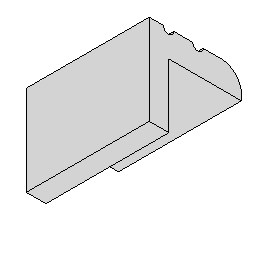

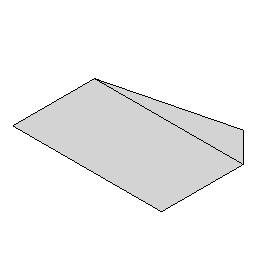

In [113]:
vid = "20"
for img_idx in all_closest_emb_list[8]:
    img_path = f'./raw_data/{vid}/{all_md[img_idx]}_00{vid}.png'
    img = Image.open(img_path)
    img.show()

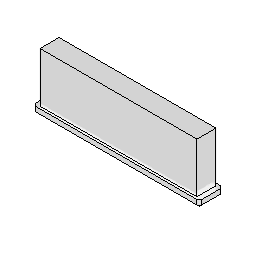

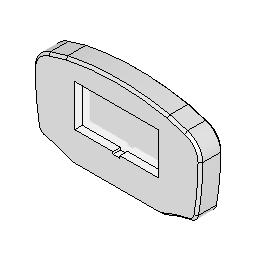

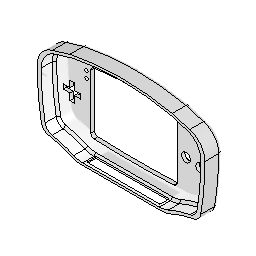

In [114]:
vid = "03"
for img_idx in all_ori_closest_emb_list[8]:
    img_path = f'./raw_data/{vid}/{all_md[img_idx]}_00{vid}.png'
    img = Image.open(img_path)
    img.show()

# Display parts

In [139]:
def image_grid(imgs, rows, cols, resize=False, texts=None):
        
    if resize:
        scale = 1/3
        w, h = imgs[0].size
        newsize = (int(w*scale), int(h*scale))
        imgs = [ img.resize(newsize) for img in imgs]

    # Width and height of the (first) image
    w, h = imgs[0].size

    # Calculate grid width and height
    grid_w = cols*w   # number of columns * width
    grid_h = rows*h
    grid = Image.new('RGB', size=(grid_w, grid_h), color="white")

    # Draw the grid
    I1 = ImageDraw.Draw(grid)
    
    for i, img in enumerate(imgs):
        x = i%cols*w
        y = i//cols*h
        grid.paste(img, box=(x, y))   # put img to the correct grid cell
        if texts is not None:
            assert len(texts) ==  len(imgs), "Should have text for each image"
            text = texts[i]
            I1.text((x, y), text, fill=(0, 0, 0))
    return grid

def create_image_grid_for_examples(png_paths):
#     png_paths = []
#     json_paths = []
    num_images_per_row = 10
    k = num_images_per_row*1
#     for s in file_stems:
#         chunk = s[0:4]
#         chunk_path = image_path / chunk
#         png_path = chunk_path / (s + ".png")
#         if png_path.exists():
#             png_paths.append(png_path)
#             json_path =  chunk_path / (s.rpartition("_")[0] + ".json")
#             assert json_path.exists(), "Json files doesn't exist"
#             json_paths.append(json_path)

            
    total_num_images = len(png_paths)
#     if total_num_images == 0:
#         print("No bodies found")
#         return None
    
    if k > total_num_images:
        k = total_num_images
#     chosen_indices = random.sample(range(total_num_images), k=k)
  
    imgs = []  # Stores images to be displayed
#     texts = []
    for i in range(k):
        png_file = png_paths[i]
#         json_file = json_paths[i]
        img = Image.open(png_file)
        imgs.append(img)
        
    num_images = len(imgs)
#     sq_max = math.ceil(math.sqrt(num_images))
#     grid = image_grid(imgs, sq_max, sq_max, resize=False, texts=None)
    grid = image_grid(imgs, 1, num_images, resize=True, texts=None)
    return grid

In [121]:
def extend_metadata_to_filepath(img_name_list_without_vid, vid):
    img_name_list_with_vid = []
    for i, im in enumerate(img_name_list_without_vid):
        img_name_list_with_vid.append(f'./raw_data/{vid}/{im}_00{vid}.png')
    
    return img_name_list_with_vid

In [127]:
def display_image_grid(msg, image_path):
    display(Markdown(msg))
#     file_stems = file_stem_dict[face_bin]
    img =  create_image_grid_for_examples(image_path)
    if img is not None:
        display(img)
    print(" ")
    print(" ")

In [141]:
img_md_list = []
for img_idx in all_ori_closest_emb_list[3]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

In [142]:
vid = '00'
img_name_list = extend_metadata_to_filepath(img_md_list, vid)

msg

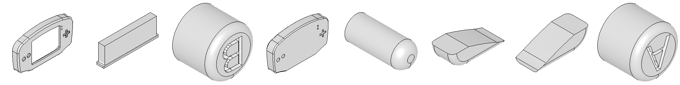

In [143]:
display_image_grid("msg", img_name_list)